### Elliot Wolf
### CS6220
### HW2

## Part 1.) Data Generator

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Create function: generate_noisy_dataset()
I prompted Claude to help with some parts of this function such as sampling x uniformly at random and some debugging steps so I could focus more on the analysis in the proceeding parts rather than focusing on generating this dataset. Main step I needed help with was creating the matrix for X, where we used column_stack to create additional columns for each inputted function.

In [2]:
def generate_noisy_dataset(functions, function_true, x_val_range, n, noise_parameter, seed=60):
    
    # Create random generator
    random_generator = np.random.default_rng(seed)

    # Limit generator to x_val_range, and make its distribution uniform. Generate n samples
    x_min, x_max = x_val_range
    x = random_generator.uniform(x_min, x_max, n)

    # Create input vector for x values, but also all additional inputted functions
    X = np.column_stack([x] + [f(x) for f in functions])

    # noise defined as range of noise_parameter values, randomly assign for each y
    noise = random_generator.uniform(-noise_parameter, noise_parameter, n)
    y = function_true(x) + noise

    return X, y
    

Example using assignment's values:

In [3]:
X, y = generate_noisy_dataset(
    functions = [lambda x: x**2, lambda x: x**3],
    function_true = np.log,
    x_val_range = (0.0, 1.0),
    n = 10,
    noise_parameter = 0.1
)

In [4]:
print(X[:1])
print(y[:1])

[[0.32428381 0.10515999 0.03410168]]
[-1.0903276]


Split into 80% train, 20% test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 60)

## Part 2.) Linear Regression

Basically did the same similar exercise in my first ML HW, computing these steps manually instead of using a library.

### Training

In [6]:

def fit(X_train, y_train):

    # Convert training data into corresponding (X,Y)
    # X: need to add a column of 1's for the intercept
    X = np.column_stack([np.ones(X_train.shape[0]), X_train])

    Y = y_train # Nothing changes here

    # Compute beta 
    beta = np.linalg.inv(X.T @ X) @ (X.T @ Y)

    return beta
                         

### Prediction

In [7]:
def predict(beta, X_test):

    # X needs a column of 1's just like in fit()
    X = np.column_stack([np.ones(X_test.shape[0]), X_test])
    
    y_pred = X @ beta

    return y_pred

### Evaluation

In [8]:
def evaluate_model(y_pred, y_true):

    # Compute MSE:
    mse = np.mean((y_pred - y_true) ** 2)

    # Compute RMSE:
    rmse = np.sqrt(mse)

    return rmse

### Linear Regression Analysis

##### Report's questions 3-7

### 3.)

Train, test, and evaluate your linear regression implementation for all setup
combinations shown below. For each combination, use the data generator to create the dataset
and show a scatterplot of the training data. Then add to it a plot of the true function and the
linear model:

a. Values of x are in range [0, 1]. The input data only has columns (x, y), i.e., the list of
additional functions of x is empty.

b. True functions [Linear f(x) = 2x + 1, Cubic f(x) = 0.5x³ - x² + x].

c. Noise levels [0.01, 0.1].

d. Data size 1000.

I had Claude help create the step_3 function to save some time creating visually appealing scatterplots so I could focus on the analysis. The skeleton was easy to create because we follow the same pattern above of generating data, training/predicting/evaluating, so I used Claude to help make these steps repeatable for different inputs and create plots.

In [9]:
# our f(x) functions are:
def linear(x):
    return 2*x + 1

def cubic(x):
    return 0.5*x**3 - x**2 + x


def step_3(function_true, functions, noise, title):

    # Generate data, split
    X, y = generate_noisy_dataset(functions, function_true, (0.0, 1.0), 1000, noise)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 60)

    # Train
    beta = fit(X_train, y_train)
    rmse_train = evaluate_model(predict(beta, X_train), y_train)
    rmse_test = evaluate_model(predict(beta, X_test), y_test)

    # Plot
    x_line = np.linspace(0, 1, 200)
    X_line = np.column_stack([x_line] + [f(x_line) for f in functions])

    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[:, 0], y_train, s=5, alpha=0.4, label= "Train")
    plt.plot(x_line, function_true(x_line), color="black", label="True function")
    plt.plot(x_line, predict(beta, X_line), color="red", linestyle="--", label="Linear model")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

    #print(f"beta = {beta}")
    print(f"Train RMSE = {rmse_train:.4f}, Test RMSE = {rmse_test:.4f}")

    return beta
    

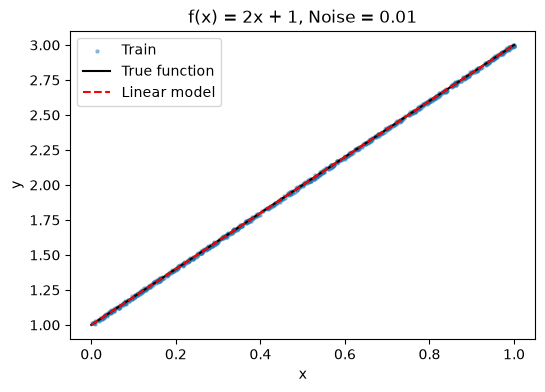

Train RMSE = 0.0057, Test RMSE = 0.0059


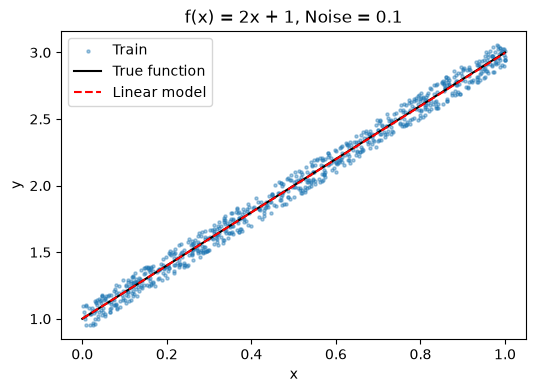

Train RMSE = 0.0569, Test RMSE = 0.0589


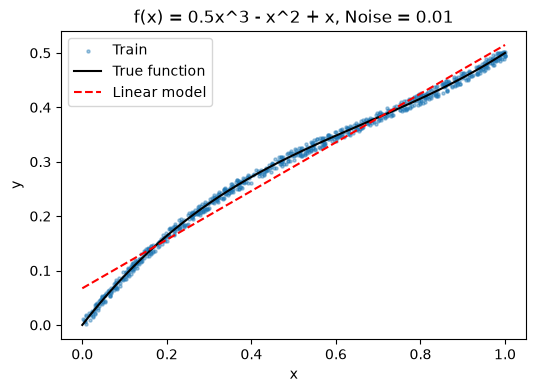

Train RMSE = 0.0211, Test RMSE = 0.0222


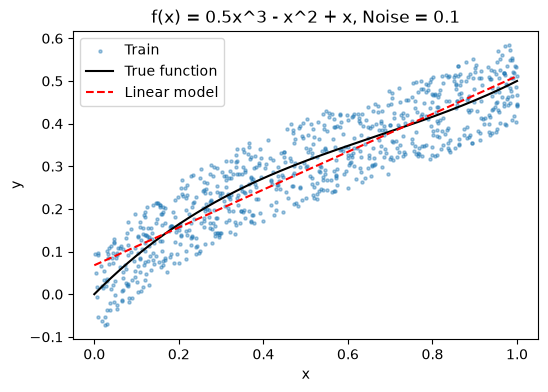

Train RMSE = 0.0598, Test RMSE = 0.0617


In [10]:
# Plug in various combos here
beta_linear_less_noise = step_3(linear, [], 0.01, "f(x) = 2x + 1, Noise = 0.01")
beta_linear_more_noise = step_3(linear, [], 0.1, "f(x) = 2x + 1, Noise = 0.1")
beta_cubic_less_noise = step_3(cubic, [], 0.01, "f(x) = 0.5x^3 - x^2 + x, Noise = 0.01")
beta_cubic_more_noise = step_3(cubic, [], 0.1, "f(x) = 0.5x^3 - x^2 + x, Noise = 0.1")

### 4.)

Repeat all the above linear regression experiments, but before doing so, add artificial
columns f_1(x)=x^2 and f_2(x)=x^3 to the input data. Show each scatterplot with true function and
“linear” model like above. For the linear model, make sure to plot the entire function. For
instance, with coefficients 0.1, 0.2, 0.3, and 0.4, you would plot 0.1+0.2x+0.3x2+0.4x3
. Do the extra columns improve the linear model?

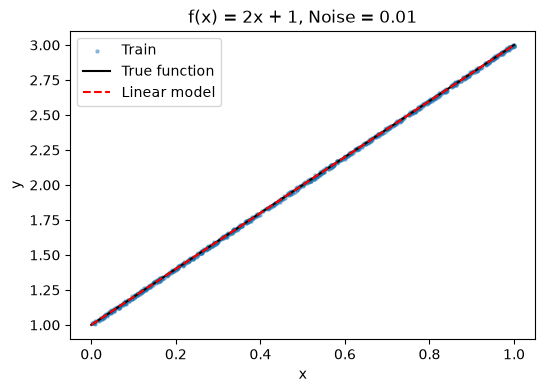

Train RMSE = 0.0057, Test RMSE = 0.0059


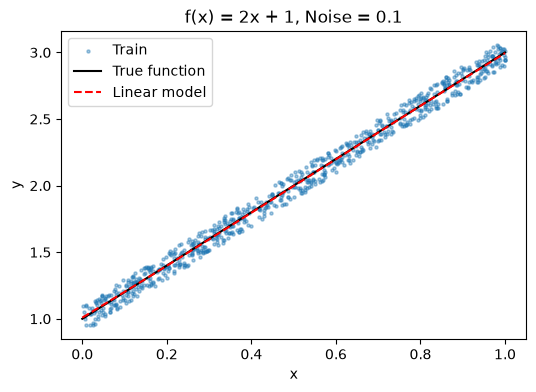

Train RMSE = 0.0569, Test RMSE = 0.0589


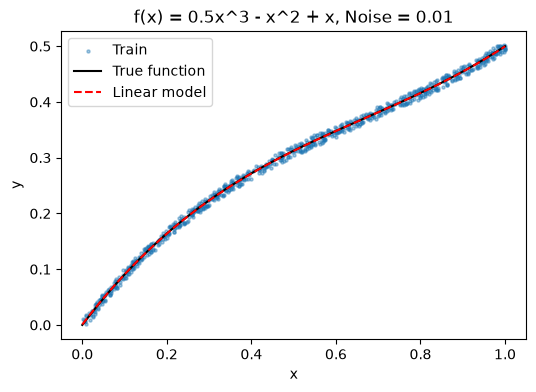

Train RMSE = 0.0057, Test RMSE = 0.0059


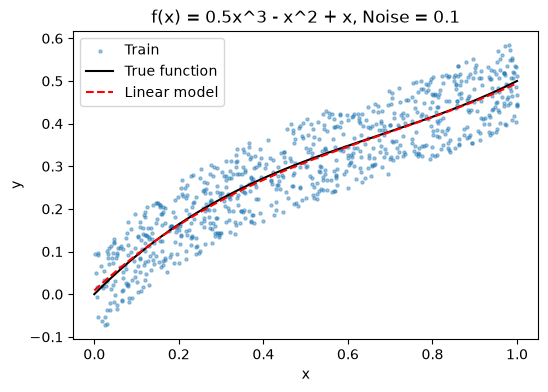

Train RMSE = 0.0569, Test RMSE = 0.0589


In [11]:
artificial_columns = [lambda x: x**2, lambda x: x**3]
# Same as before, just imple
beta_linear_less_noise_2 = step_3(linear, artificial_columns, 0.01, "f(x) = 2x + 1, Noise = 0.01")
beta_linear_more_noise_2 = step_3(linear, artificial_columns, 0.1, "f(x) = 2x + 1, Noise = 0.1")
beta_cubic_less_noise_2 = step_3(cubic, artificial_columns, 0.01, "f(x) = 0.5x^3 - x^2 + x, Noise = 0.01")
beta_cubic_more_noise_2 = step_3(cubic, artificial_columns, 0.1, "f(x) = 0.5x^3 - x^2 + x, Noise = 0.1")

### 5.)

Report the error for data point (x,y) = (10, f(10)) for each of the setup combinations above, both for the (x,y) data and the (x,x2,x3,y) data. In which case is the prediction “good”?

Again, used Claude to help create the function so I could focus on the analysis. The only help I needed here was the use of np.column_stack(...)

In [12]:
def step_5(beta, function_true, functions, label):

    x = np.array([10.0])
    X_point = np.column_stack([x] + [f(x) for f in functions])

    y_pred = predict(beta, X_point)[0]
    y_true = function_true(10)

    print(f"{label}: prediction = {y_pred:.4f}, y = f(10) = {y_true:.4f}, error = {y_pred - y_true:.4f}")

In [13]:
# (x,y)
step_5(beta_linear_less_noise, linear, [], "Linear, noise=0.01")
step_5(beta_linear_more_noise, linear, [], "Linear, noise=0.1")
step_5(beta_cubic_less_noise, cubic, [], "Cubic, noise=0.01")
step_5(beta_cubic_more_noise, cubic, [], "Cubic, noise=0.1")


# (x, x^2, x^3, y)
step_5(beta_linear_less_noise_2, linear, artificial_columns, "Linear, noise=0.01 (x,x^2,x^3)")
step_5(beta_linear_more_noise_2, linear, artificial_columns, "Linear, noise=0.1 (x,x^2,x^3)")
step_5(beta_cubic_less_noise_2, cubic, artificial_columns, "Cubic, noise=0.01 (x,x^2,x^3)")
step_5(beta_cubic_more_noise_2, cubic, artificial_columns, "Cubic, noise=0.1 (x,x^2,x^3)")

Linear, noise=0.01: prediction = 20.9958, y = f(10) = 21.0000, error = -0.0042
Linear, noise=0.1: prediction = 20.9582, y = f(10) = 21.0000, error = -0.0418
Cubic, noise=0.01: prediction = 4.5403, y = f(10) = 410.0000, error = -405.4597
Cubic, noise=0.1: prediction = 4.5026, y = f(10) = 410.0000, error = -405.4974
Linear, noise=0.01 (x,x^2,x^3): prediction = 12.7012, y = f(10) = 21.0000, error = -8.2988
Linear, noise=0.1 (x,x^2,x^3): prediction = -61.9885, y = f(10) = 21.0000, error = -82.9885
Cubic, noise=0.01 (x,x^2,x^3): prediction = 401.7012, y = f(10) = 410.0000, error = -8.2988
Cubic, noise=0.1 (x,x^2,x^3): prediction = 327.0115, y = f(10) = 410.0000, error = -82.9885


### 6.)

See HW2 PDF for discussion.

### 7.)

I again had Claude help out with the function creation and plotting so I could focus on the interpretation. This was the first step I had claude write the entire function, I felt like I was spending too much time on the function instead of the value of the result.

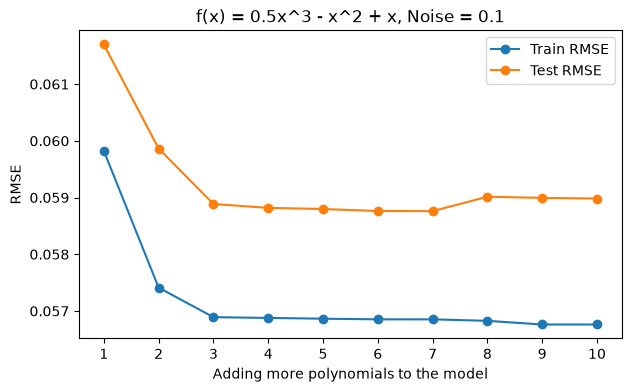

In [16]:
def step_7(max_power=10):
    train_rmses, test_rmses = [], []

    for power in range(1, max_power+1):

        functions = [lambda x, p=p: x**p for p in range(2, power+1)]

        X, y = generate_noisy_dataset(functions, cubic, (0.0, 1.0), 1000, 0.1)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

        beta = fit(X_train, y_train)
        train_rmses.append(evaluate_model(predict(beta, X_train), y_train))
        test_rmses.append(evaluate_model(predict(beta, X_test), y_test))

    powers = range(1, max_power + 1)
    
    plt.figure(figsize=(7,4))
    plt.plot(powers, train_rmses, marker="o", label="Train RMSE")
    plt.plot(powers, test_rmses, marker="o", label="Test RMSE")
    plt.xticks(powers)
    plt.xlabel("Adding more polynomials to the model")
    plt.ylabel("RMSE")
    plt.title("f(x) = 0.5x^3 - x^2 + x, Noise = 0.1")
    plt.legend()
    plt.show()

    return train_rmses, test_rmses

train_rmses, test_rmses = step_7()
    
    

## Part 3.) Regression Tree

Claude prompt and pseudocode is in the PDF. Claude helped convert the pseudo into python, which was a huge help on creating classes, which I haven't done since Spring '25. Code was a lot lengthier than I thought it'd be. Claude also recommended a Node class in addition to the RegressionTree class

In [18]:
from collections import deque

class Node:

    def __init__(self):
        self.attribute = None
        self.threshold = None
        self.split_x = None
        self.left = None
        self.right = None
        self.prediction = None
        self.n_records = 0

    def is_leaf(self):
            return self.prediction is not None

In [19]:
class RegressionTree:

    def __init__(self):
        self.root = None

    def _split_score(self, X, y, attribute, threshold):
        left_mask = X[:, attribute] <= threshold
        y_left, y_right = y[left_mask], y[~left_mask]

        if len(y_left) == 0 or len(y_right) == 0:
            return -np.inf

        n = len(y)
        children_variance = (len(y_left) * np.var(y_left) + len(y_right) * np.var(y_right)) / n
        return np.var(y) - children_variance

    def _is_leaf(self, X, y, min_records):
        if len(y) < min_records:
            return True
        if np.all(y == y[0]):
            return True
        if np.all(X == X[0]):
            return True
        return False

    def _expand_node(self, node, X, y):
        best_score, best_attribute, best_threshold = -np.inf, None, None

        for attribute in range(X.shape[1]):
            for threshold in np.unique(X[:, attribute]):
                score = self._split_score(X, y, attribute, threshold)
                if score > best_score:
                    best_score, best_attribute, best_threshold = score, attribute, threshold

        node.attribute, node.threshold = best_attribute, best_threshold

        left_mask = X[:, best_attribute] <= best_threshold
        node.split_x = X[left_mask, 0].max() 

        return (Node(), X[left_mask], y[left_mask]), (Node(), X[~left_mask], y[~left_mask])

    # ---------- fit (main function) ----------
    def fit(self, dataset, min_records):

        X, y = dataset
        self.root = Node()

        work_q = deque([(self.root, X, y)])
        while work_q:
            node, X_node, y_node = work_q.popleft()   
            node.n_records = len(y_node)

            if self._is_leaf(X_node, y_node, min_records):
                node.prediction = y_node.mean()       
            else:
                left, right = self._expand_node(node, X_node, y_node)
                node.left, node.right = left[0], right[0]  
                work_q.append(left)
                work_q.append(right)
        return self

    # ---------- predict ----------
    def predict(self, X):
        X = np.atleast_2d(X)
        predictions = np.empty(len(X))
        for i, record in enumerate(X):
            node = self.root
            while not node.is_leaf():
                node = node.left if record[node.attribute] <= node.threshold else node.right
            predictions[i] = node.prediction
        return predictions

    # ---------- visualize ----------
    def visualize(self, x_range=(0.0, 1.0), functions=(), ax=None):
        if ax is None:
            _, ax = plt.subplots()

        # Split points, in x units
        for node in self._nodes():
            if not node.is_leaf():
                ax.axvline(node.split_x, color="gray", linewidth=0.5, alpha=0.5)

        x_grid = np.linspace(x_range[0], x_range[1], 2000)
        X_grid = np.column_stack([x_grid] + [f(x_grid) for f in functions])
        ax.plot(x_grid, self.predict(X_grid), color="red", linewidth=1.5, label="tree prediction")

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        return ax

    # ---------- helpers (tree size, leaf sizes) ----------
    def _nodes(self):
        nodes, stack = [], [self.root]
        while stack:
            node = stack.pop()
            nodes.append(node)
            if not node.is_leaf():
                stack.extend([node.left, node.right])
        return nodes

    def n_nodes(self):
        return len(self._nodes())

    def leaf_sizes(self):
        return [node.n_records for node in self._nodes() if node.is_leaf()]

#### Report Question 9

My linear regression code was somewhat chunky and I had a few lines that could've been thrown in a function/loop instead of computing separately for each function/noiselevel/schema combo. Prompted Claude to create an algorithm to take in all of these various arguments and produce the various output combos to save time and focus on meaning. 

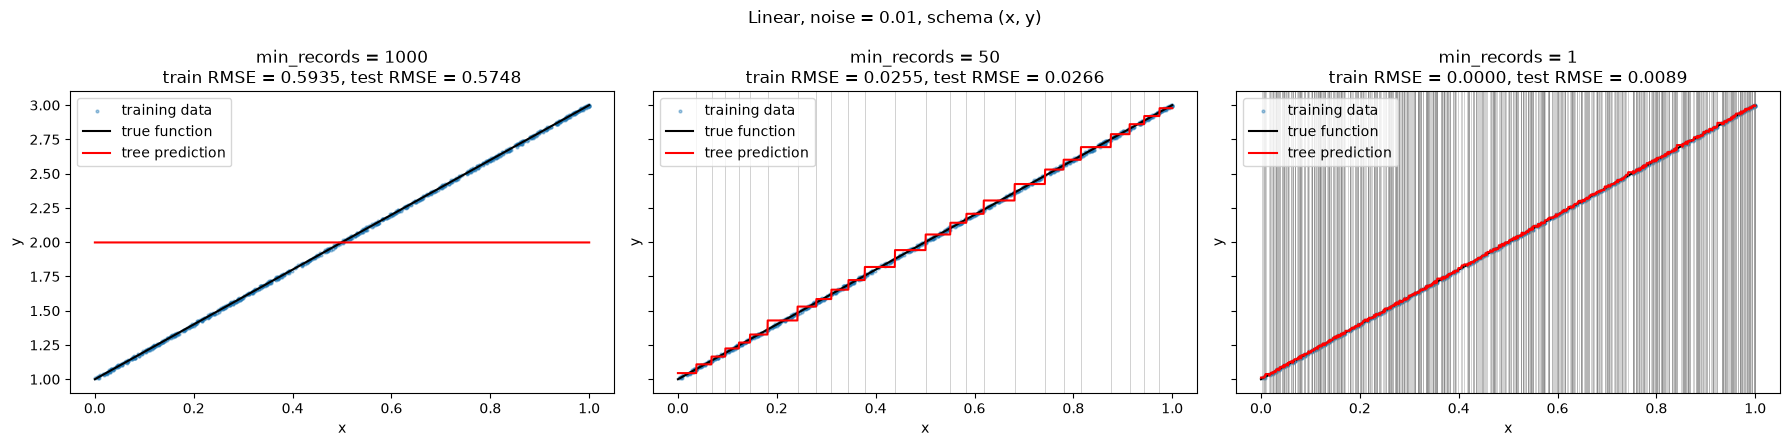

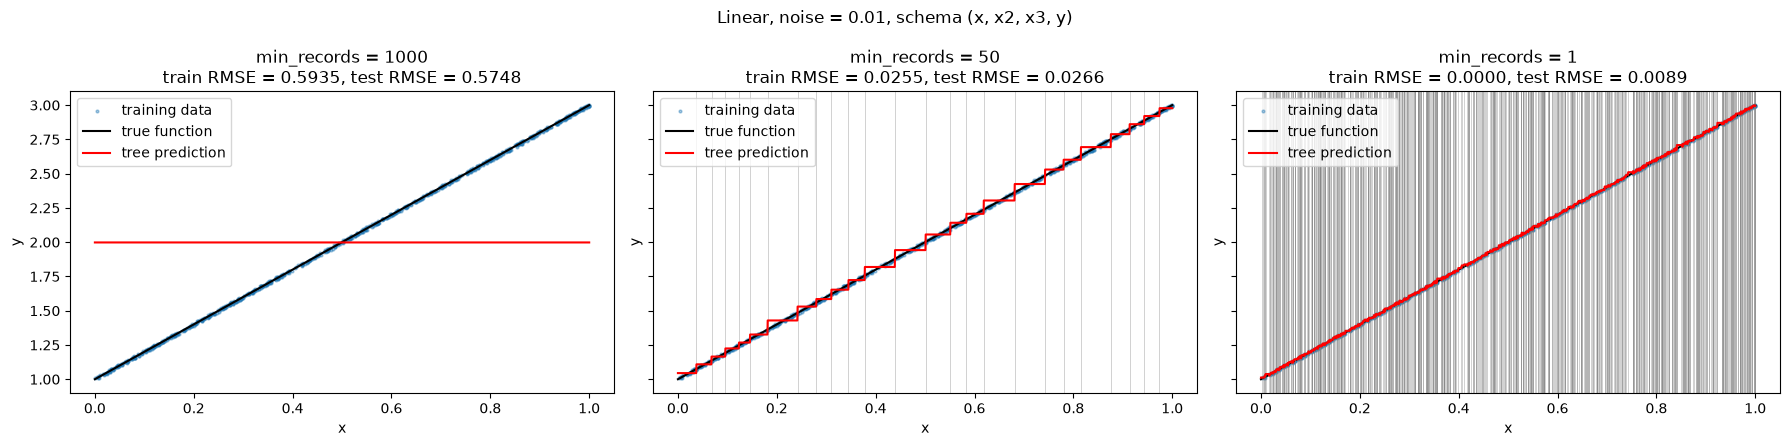

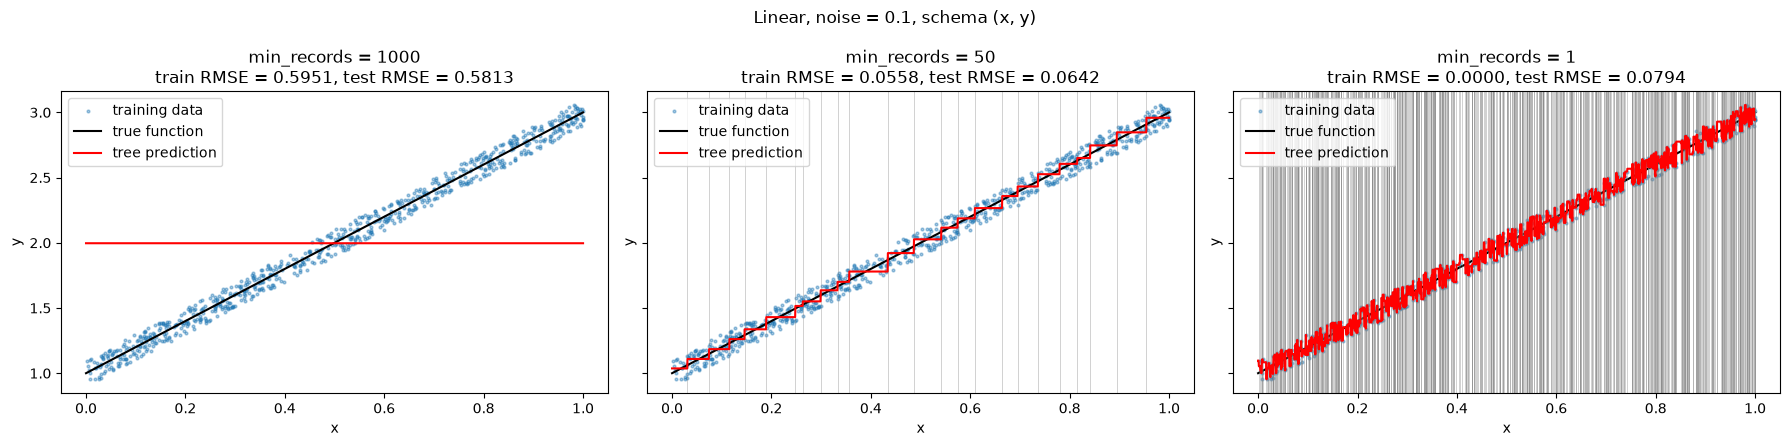

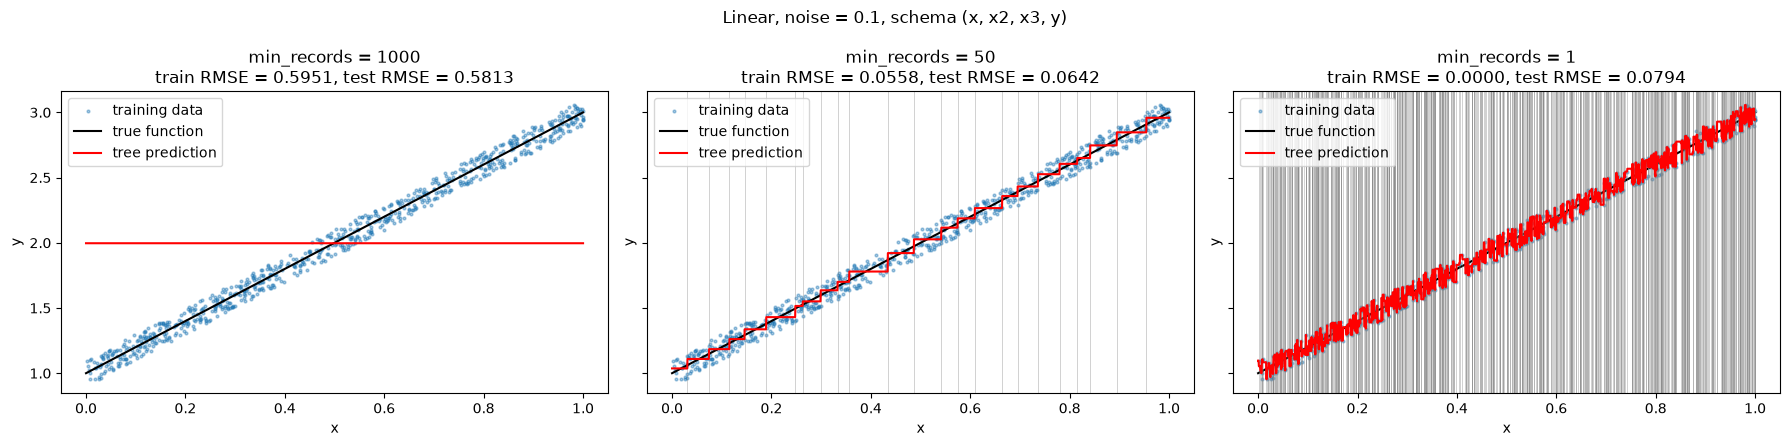

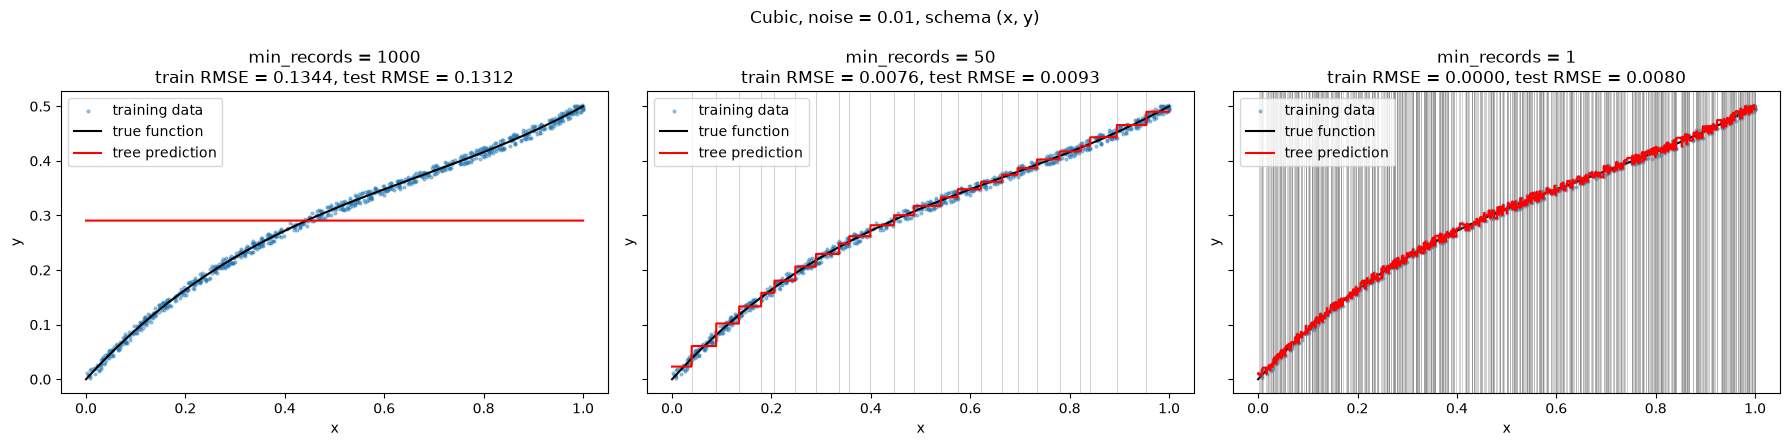

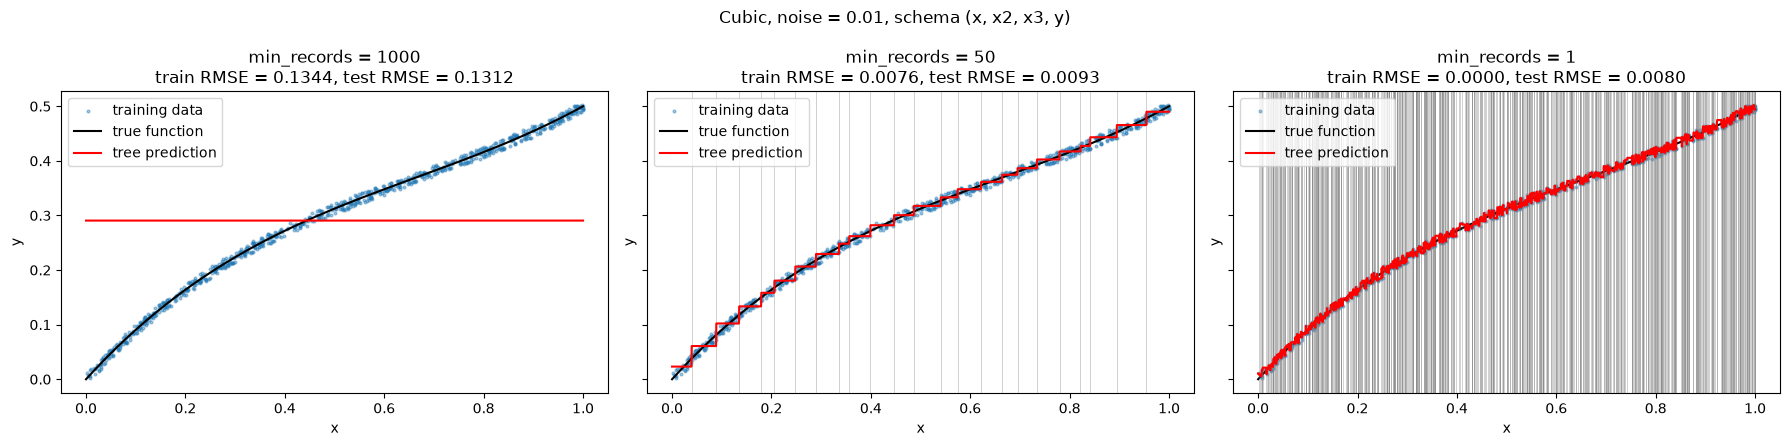

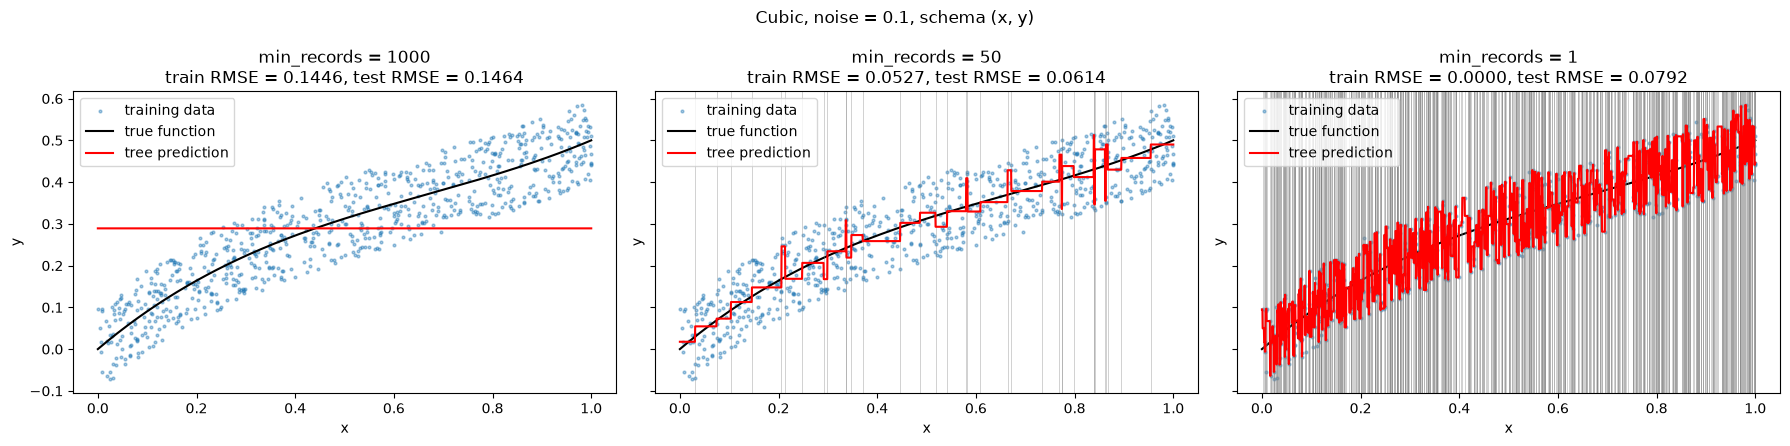

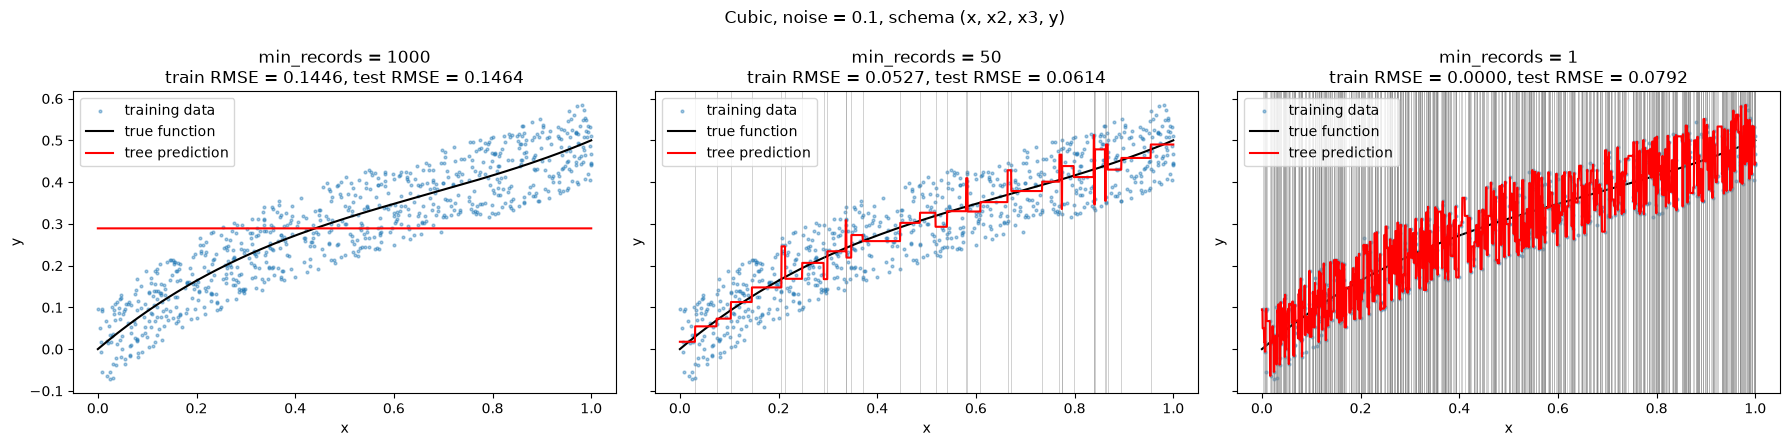

In [20]:
true_functions = {"Linear": lambda x: 2 * x + 1,
                  "Cubic": lambda x: 0.5 * x**3 - x**2 + x}
schemas = {"(x, y)": [],
           "(x, x2, x3, y)": [lambda x: x**2, lambda x: x**3]}
noise_levels = [0.01, 0.1]
min_records_list = [1000, 50, 1]

tree_results = []   # one row per setup combination
x_line = np.linspace(0, 1, 200)

for f_name, f_true in true_functions.items():
    for noise in noise_levels:
        for schema_name, functions in schemas.items():
            # Same data and same split as in the linear regression part
            X, y = generate_noisy_dataset(functions, f_true, (0, 1), 1000, noise)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

            fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
            for ax, min_records in zip(axes, min_records_list):
                tree = RegressionTree().fit((X_train, y_train), min_records)
                train_rmse = evaluate_model(tree.predict(X_train), y_train)
                test_rmse = evaluate_model(tree.predict(X_test), y_test)

                # Scatterplot of training data, true function, tree visualization
                ax.scatter(X_train[:, 0], y_train, s=4, alpha=0.4, label="training data")
                ax.plot(x_line, f_true(x_line), color="black", linewidth=1.5, label="true function")
                tree.visualize(x_range=(0, 1), functions=functions, ax=ax)
                ax.set_title(f"min_records = {min_records}\ntrain RMSE = {train_rmse:.4f}, test RMSE = {test_rmse:.4f}")
                ax.legend(loc="upper left")

                leaf_sizes = tree.leaf_sizes()
                tree_results.append({"function": f_name, "noise": noise, "schema": schema_name,
                                     "min_records": min_records, "train_rmse": train_rmse,
                                     "test_rmse": test_rmse, "nodes": tree.n_nodes(),
                                     "leaves": len(leaf_sizes), "min_leaf": min(leaf_sizes),
                                     "max_leaf": max(leaf_sizes)})

            fig.suptitle(f"{f_name}, noise = {noise}, schema {schema_name}")
            fig.tight_layout()
            plt.show()

### 11.)

Code generated by Claude, am running out of time and wanted to be able to interpret

min_records =   2: nodes = 319, train RMSE = 0.0000, test RMSE = 0.1778
min_records =   4: nodes = 161, train RMSE = 0.0483, test RMSE = 0.1507
min_records =   8: nodes =  73, train RMSE = 0.0808, test RMSE = 0.1452
min_records =  16: nodes =  33, train RMSE = 0.1085, test RMSE = 0.1480
min_records =  32: nodes =  17, train RMSE = 0.1418, test RMSE = 0.1802
min_records =  64: nodes =   9, train RMSE = 0.2271, test RMSE = 0.2870
min_records = 128: nodes =   3, train RMSE = 0.3130, test RMSE = 0.3358
min_records = 256: nodes =   1, train RMSE = 0.6689, test RMSE = 0.7226


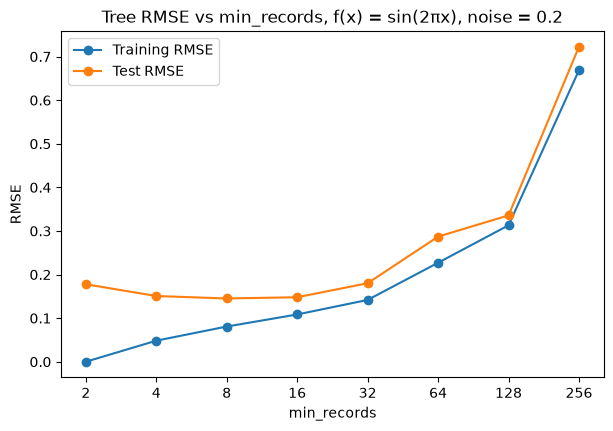

In [23]:
f_sine = lambda x: np.sin(2 * np.pi * x)
X, y = generate_noisy_dataset([], f_sine, (0, 1), 200, 0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

min_records_values = [2, 4, 8, 16, 32, 64, 128, 256]
train_rmses, test_rmses, node_counts = [], [], []

for min_records in min_records_values:
    tree = RegressionTree().fit((X_train, y_train), min_records)
    train_rmses.append(evaluate_model(tree.predict(X_train), y_train))
    test_rmses.append(evaluate_model(tree.predict(X_test), y_test))
    node_counts.append(tree.n_nodes())
    print(f"min_records = {min_records:>3}: nodes = {node_counts[-1]:>3}, "
          f"train RMSE = {train_rmses[-1]:.4f}, test RMSE = {test_rmses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(min_records_values, train_rmses, marker="o", label="Training RMSE")
ax.plot(min_records_values, test_rmses, marker="o", label="Test RMSE")
ax.set_xscale("log", base=2)              # min_records doubles each step
ax.set_xticks(min_records_values)
ax.set_xticklabels(min_records_values)
ax.set_xlabel("min_records")
ax.set_ylabel("RMSE")
ax.set_title("Tree RMSE vs min_records, f(x) = sin(2πx), noise = 0.2")
ax.legend()
plt.show()